# `Image deblurring`

## **Imports**

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from PIL import Image
import io
import requests

## `1. Load image: Step 1`

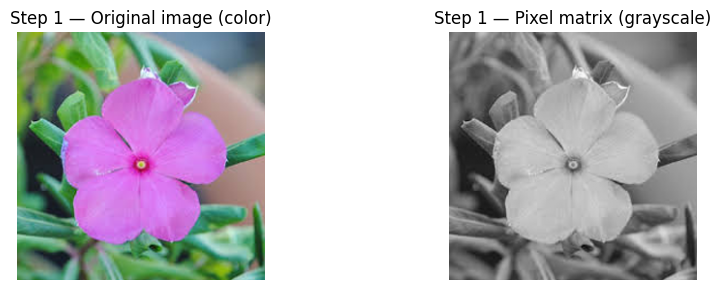

Matrix shape: (256, 256)
Sample values (top-left 4×4):
[[103.33 106.   112.   118.67]
 [104.33 107.67 113.   119.67]
 [106.   109.33 115.   121.67]
 [108.33 111.67 117.33 123.33]]


In [13]:
img = Image.open("./image1.jpeg").convert("RGB").resize((256,256))

color_array = np.array(img).astype(np.float64)
A = np.mean(color_array, axis=2) 

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(color_array.astype(np.uint8))
plt.title("Step 1 — Original image (color)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(A, cmap="gray", vmin=0, vmax=255)
plt.title("Step 1 — Pixel matrix (grayscale)")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Matrix shape: {A.shape}")
print(f"Sample values (top-left 4×4):\n{np.round(A[:4,:4], 2)}")

## 2. `Step 2: build kernel + apply blur`

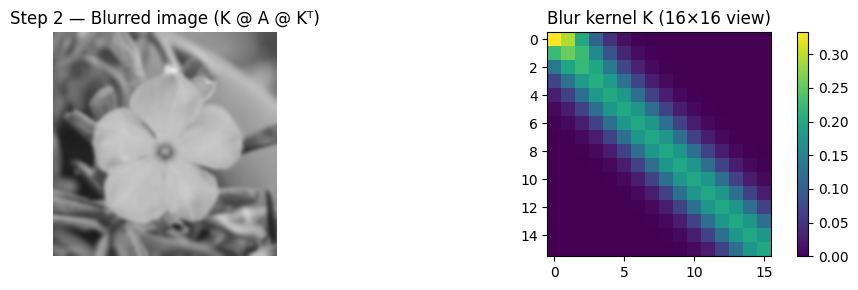

Rank: 256   Nullity: 0   Condition number: 184635311.71

RREF (top 4×4):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

L (LU decomp, 4×4):
[[1.    0.    0.    0.   ]
 [0.406 1.    0.    0.   ]
 [0.082 0.536 1.    0.   ]
 [0.007 0.088 0.436 1.   ]]

U (LU decomp, 4×4):
[[0.333 0.294 0.202 0.108]
 [0.    0.077 0.141 0.152]
 [0.    0.    0.03  0.087]
 [0.    0.    0.    0.013]]


In [14]:
def build_gaussian_kernel(size, sigma=2.0):
    K = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            diff = abs(i - j)
            # Only calculate values near the diagonal (local neighborhood)
            if diff < 15:  # Local window size
                K[i, j] = np.exp(-0.5 * (diff / sigma) ** 2)
    # Normalize rows so the image brightness doesn't change
    row_sums = K.sum(axis=1)
    return K / row_sums[:, np.newaxis]


def numpy_rref(matrix, size=4):
    M = matrix[:size, :size].astype(float).copy()
    for col in range(size):
        pivot = next((r for r in range(col, size) if abs(M[r, col]) > 1e-10), None)
        if pivot is None:
            continue
        M[[col, pivot]] = M[[pivot, col]]
        M[col] /= M[col, col]
        for row in range(size):
            if row != col:
                M[row] -= M[row, col] * M[col]
    return np.round(M, 2)


size = A.shape[0]
K = build_gaussian_kernel(size, sigma=2.0)
B = np.clip(K @ A @ K.T, 0, 255)

P_lu, L, U = lu(K[:8, :8])
rank = int(np.linalg.matrix_rank(K))
nullity = size - rank
cond = round(float(np.linalg.cond(K)), 2)
rref = numpy_rref(K)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(B, cmap="gray", vmin=0, vmax=255)
plt.title("Step 2 — Blurred image (K @ A @ Kᵀ)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(K[:16, :16], cmap="viridis")
plt.colorbar()
plt.title("Blur kernel K (16×16 view)")
plt.tight_layout()
plt.show()

print(f"Rank: {rank}   Nullity: {nullity}   Condition number: {cond}")
print(f"\nRREF (top 4×4):\n{rref}")
print(f"\nL (LU decomp, 4×4):\n{np.round(L[:4,:4], 3)}")
print(f"\nU (LU decomp, 4×4):\n{np.round(U[:4,:4], 3)}")

## `Step 3: Subspaces`

In [15]:
Usvd, S, Vt = np.linalg.svd(K)

col_space = Usvd[:, :rank]      
null_space = Vt[rank:]          

print(f"Rank-Nullity theorem: rank({rank}) + nullity({nullity}) = {rank+nullity} = n")
print(f"\nColumn space basis (first 3 vectors, first 4 elements):")
print(np.round(col_space[:4, :3].T, 4))
print(f"\nNull space basis (first 3 vectors, first 4 elements):")
if len(null_space) > 0:
    print(np.round(null_space[:3, :4], 4))
else:
    print("Empty — K is full rank, no null space")

Rank-Nullity theorem: rank(256) + nullity(0) = 256 = n

Column space basis (first 3 vectors, first 4 elements):
[[ 0.0936  0.097   0.1002  0.1027]
 [-0.1045 -0.1083 -0.1119 -0.1146]
 [ 0.0687  0.0712  0.0735  0.0752]]

Null space basis (first 3 vectors, first 4 elements):
Empty — K is full rank, no null space


## `step 4: linear independence + basis`

In [16]:
Q_qr, R_qr = np.linalg.qr(K)
diag_R = np.abs(np.diag(R_qr))
threshold = diag_R.max() * 1e-10
independent_cols = [i for i, d in enumerate(diag_R) if d > threshold][:rank]

singular_values = np.linalg.svd(K, compute_uv=False)

print(f"Independent columns (via QR): first {len(independent_cols)} — indices {independent_cols[:8]}")
print(f"\nTop singular values: {np.round(singular_values[:6], 4)}")
print(f"\nBasis preview (rows of K at independent cols, 4×4):")
print(np.round(K[independent_cols[:4], :4], 3))

Independent columns (via QR): first 256 — indices [0, 1, 2, 3, 4, 5, 6, 7]

Top singular values: [1.0004 1.0003 0.9992 0.9977 0.9955 0.9928]

Basis preview (rows of K at independent cols, 4×4):
[[0.333 0.294 0.202 0.108]
 [0.227 0.257 0.227 0.156]
 [0.135 0.196 0.222 0.196]
 [0.067 0.126 0.183 0.207]]


## `Step 5: Gram-Schmidt orthogonalization`

In [17]:
def gram_schmidt(vectors):
    basis = []
    for v in vectors:
        w = v.copy().astype(float)
        for b in basis:
            w -= np.dot(w, b) * b
        norm = np.linalg.norm(w)
        if norm > 1e-10:
            basis.append(w / norm)
    return np.array(basis)


vectors = [K[:, i] for i in range(min(rank, 10))]
ortho = gram_schmidt(vectors)

dot_check = float(np.dot(ortho[0], ortho[1]))
print(f"Vectors in: {len(vectors)}   Orthogonal vectors out: {len(ortho)}")
print(f"Dot product between first two vectors: {dot_check:.2e}")
print(f"Orthogonality confirmed: {abs(dot_check) < 1e-6}")
print(f"\nOrthogonal basis preview (3 vectors, 4 elements each):")
print(np.round(ortho[:3, :4], 4))

Vectors in: 10   Orthogonal vectors out: 10
Dot product between first two vectors: -7.49e-16
Orthogonality confirmed: True

Orthogonal basis preview (3 vectors, 4 elements each):
[[ 0.7719  0.5266  0.3131  0.1563]
 [-0.4932  0.2014  0.5304  0.528 ]
 [ 0.3108 -0.4296 -0.2893  0.2091]]


## `Step 6: Projection`

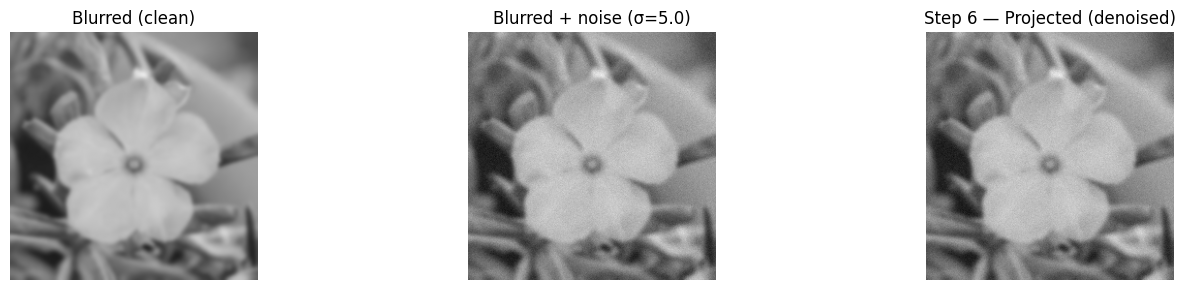

P² = P (idempotent): True
Projection matrix preview (4×4):
[[ 1.  0. -0.  0.]
 [ 0.  1.  0. -0.]
 [-0.  0.  1.  0.]
 [ 0. -0.  0.  1.]]


In [18]:
# Add noise to the blurred image first
noise_std = 5.0
B_noisy = B + np.random.normal(0, noise_std, B.shape)

P_proj = K @ np.linalg.pinv(K)
projected = np.clip(P_proj @ B_noisy, 0, 255)
is_idempotent = np.allclose(P_proj @ P_proj, P_proj, atol=1e-4)

plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.imshow(B, cmap="gray", vmin=0, vmax=255)
plt.title("Blurred (clean)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(B_noisy, cmap="gray", vmin=0, vmax=255)
plt.title(f"Blurred + noise (σ={noise_std})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(projected, cmap="gray", vmin=0, vmax=255)
plt.title("Step 6 — Projected (denoised)")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"P² = P (idempotent): {is_idempotent}")
print(f"Projection matrix preview (4×4):\n{np.round(P_proj[:4,:4], 4)}")

## `step 7: Least squares recovery`

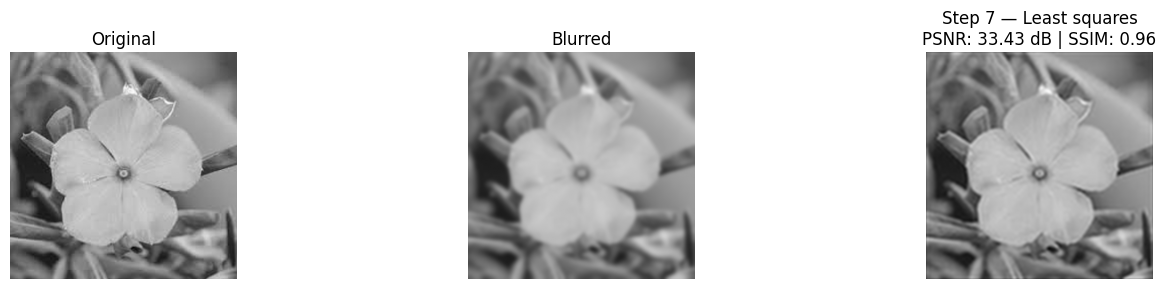

In [19]:
lam = 0.01
KtK = K.T @ K
K_reg_inv = np.linalg.solve(KtK + lam * np.eye(KtK.shape[0]), K.T)
recovered_ls = np.clip(K_reg_inv @ B @ K_reg_inv.T, 0, 255)

psnr_ls = round(float(psnr(A.astype(np.uint8), recovered_ls.astype(np.uint8), data_range=255)), 2)
ssim_ls = round(float(ssim(A.astype(np.uint8), recovered_ls.astype(np.uint8), data_range=255)), 3)

plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.imshow(A, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(B, cmap="gray", vmin=0, vmax=255)
plt.title("Blurred")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(recovered_ls, cmap="gray", vmin=0, vmax=255)
plt.title(f"Step 7 — Least squares\nPSNR: {psnr_ls} dB | SSIM: {ssim_ls}")
plt.axis("off")
plt.tight_layout()
plt.show()

## `Step 8: Eigen value analysis`

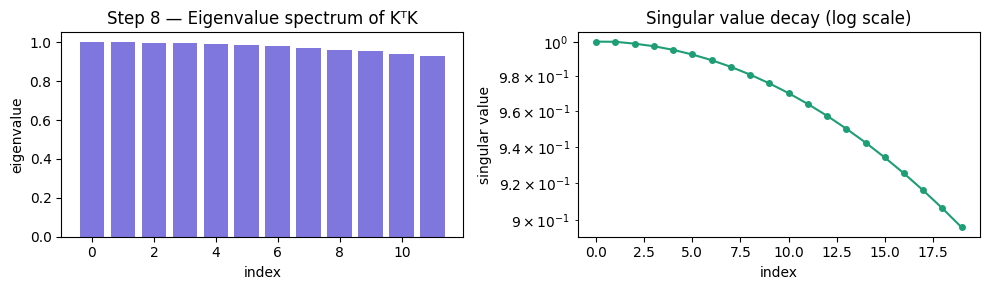

Dominant eigenvalue: 1.0008
Top 8 eigenvalues: [1.0008, 1.0006, 0.9984, 0.9954, 0.9911, 0.9857, 0.9791, 0.9714]
Top 8 singular values: [1.0004, 1.0003, 0.9992, 0.9977, 0.9955, 0.9928, 0.9895, 0.9856]


In [20]:
KtK = K.T @ K
eigenvalues = sorted(np.linalg.eigvalsh(KtK).tolist(), reverse=True)
singular_vals = np.linalg.svd(K, compute_uv=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.bar(range(12), eigenvalues[:12], color="#7F77DD")
ax1.set_title("Step 8 — Eigenvalue spectrum of KᵀK")
ax1.set_xlabel("index")
ax1.set_ylabel("eigenvalue")

ax2.semilogy(singular_vals[:20], color="#1D9E75", marker="o", markersize=4)
ax2.set_title("Singular value decay (log scale)")
ax2.set_xlabel("index")
ax2.set_ylabel("singular value")

plt.tight_layout()
plt.show()

print(f"Dominant eigenvalue: {round(eigenvalues[0], 4)}")
print(f"Top 8 eigenvalues: {[round(v,4) for v in eigenvalues[:8]]}")
print(f"Top 8 singular values: {[round(float(s),4) for s in singular_vals[:8]]}")

## `Step 9 : SVD reconstruction`

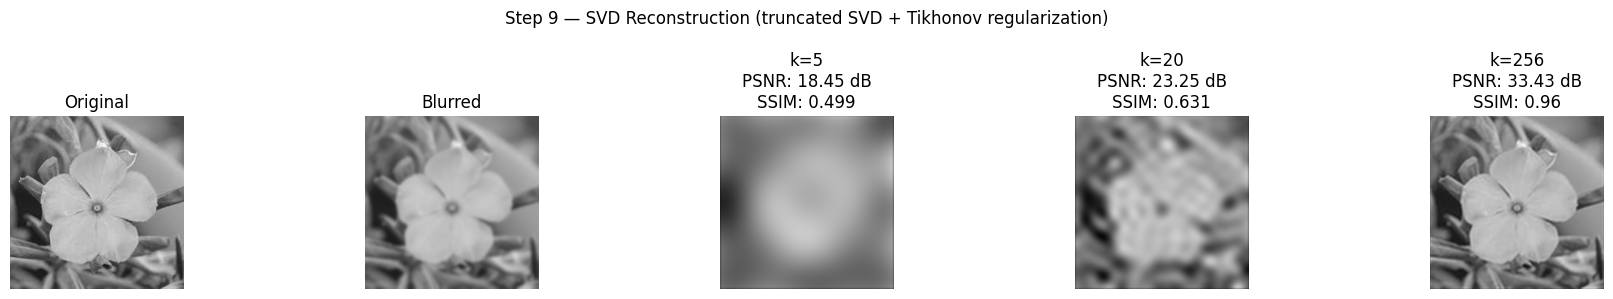

Best k: 256 → PSNR: 33.43 dB | SSIM: 0.96


In [21]:
def truncated_svd_recover(K, B, k, lam=0.01):
    U, S, Vt = np.linalg.svd(K, full_matrices=False)
    S_k, U_k, Vt_k = S[:k], U[:, :k], Vt[:k, :]
    S_inv = S_k / (S_k ** 2 + lam)     
    K_pinv = Vt_k.T @ np.diag(S_inv) @ U_k.T
    return np.clip(K_pinv @ B @ K_pinv.T, 0, 255)


k_values = [5, 20, size]
results = {}
for k in k_values:
    rec = truncated_svd_recover(K, B, k)
    results[k] = {
        "image": rec,
        "psnr": round(float(psnr(A.astype(np.uint8), rec.astype(np.uint8), data_range=255)), 2),
        "ssim": round(float(ssim(A.astype(np.uint8), rec.astype(np.uint8), data_range=255)), 3)
    }

fig, axes = plt.subplots(1, len(k_values) + 2, figsize=(18, 3))

axes[0].imshow(A, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(B, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Blurred")
axes[1].axis("off")

for i, k in enumerate(k_values):
    r = results[k]
    axes[i+2].imshow(r["image"], cmap="gray", vmin=0, vmax=255)
    axes[i+2].set_title(f"k={k}\nPSNR: {r['psnr']} dB\nSSIM: {r['ssim']}")
    axes[i+2].axis("off")

plt.suptitle("Step 9 — SVD Reconstruction (truncated SVD + Tikhonov regularization)")
plt.tight_layout()
plt.show()

best_k = max(results, key=lambda k: results[k]["psnr"])
print(f"Best k: {best_k} → PSNR: {results[best_k]['psnr']} dB | SSIM: {results[best_k]['ssim']}")

## `Final comparision:`

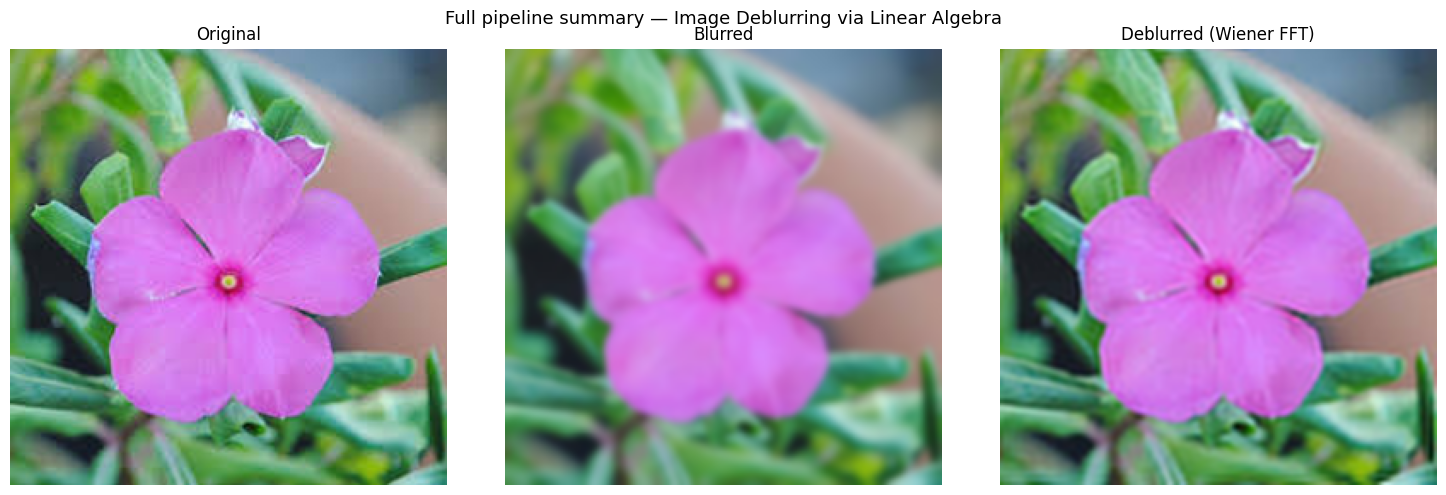

Pipeline complete.
Wiener PSNR        : 36.18 dB
Wiener SSIM        : 0.969
Least squares PSNR : 33.43 dB
Best SVD PSNR      : 33.43 dB  (k=256)


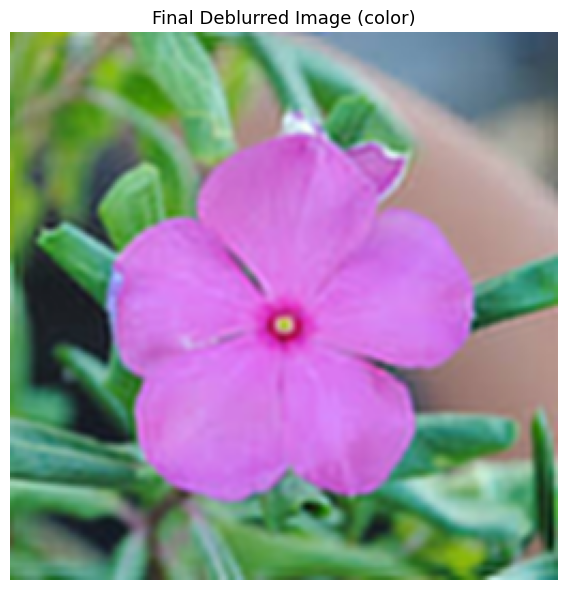

In [22]:
from numpy.fft import fft2, ifft2
from scipy.signal.windows import gaussian

def wiener_deconv_channel(blurred_ch, psf_small, K_noise=0.01):
    # Add reflected padding to reduce boundary artifacts
    pad = 20
    blurred_padded = np.pad(blurred_ch, pad, mode='reflect')
    
    h, w = blurred_padded.shape
    psf_padded = np.zeros((h, w))

    ph, pw = psf_small.shape
    cx, cy = h // 2, w // 2
    psf_padded[cx - ph//2 : cx + ph//2 + 1,
               cy - pw//2 : cy + pw//2 + 1] = psf_small

    psf_padded = np.fft.ifftshift(psf_padded)

    H = np.fft.fft2(psf_padded)
    Bf = np.fft.fft2(blurred_padded)

    W = np.conj(H) / (np.abs(H)**2 + K_noise)

    recovered = np.real(np.fft.ifft2(W * Bf))

    # Crop the padding back off
    recovered = recovered[pad:-pad, pad:-pad]

    return np.clip(recovered, 0, 255)
# ── Build compact 2D PSF ─────────────────────────────────────────────
kernel_size = 13

g1d = gaussian(kernel_size, std=2.0)
g1d /= g1d.sum()

psf_small = np.outer(g1d, g1d)
psf_small /= psf_small.sum()

psf_2d_true = np.zeros((size, size))

cx, cy = size // 2, size // 2
psf_2d_true[cx - kernel_size//2 : cx + kernel_size//2 + 1,
            cy - kernel_size//2 : cy + kernel_size//2 + 1] = psf_small

# correct FFT alignment
psf_2d_true = np.fft.ifftshift(psf_2d_true)

# ── Blur color image ─────────────────────────────────────────────────────────
color_float = color_array.astype(np.float64)
blurred_color = np.stack([
    np.clip(K @ color_float[:,:,c] @ K.T, 0, 255)
    for c in range(3)
], axis=2)

# ── Deblur each channel ──────────────────────────────────────────────────────
deblurred_color = np.stack([
    wiener_deconv_channel(blurred_color[:,:,c], psf_small, K_noise=0.001)
    for c in range(3)
], axis=2).astype(np.uint8)

# ── Metrics ──────────────────────────────────────────────────────────────────
gray_orig      = A.astype(np.uint8)
gray_deblurred = np.mean(deblurred_color.astype(np.float64), axis=2).astype(np.uint8)

psnr_wiener = round(float(psnr(gray_orig, gray_deblurred, data_range=255)), 2)
ssim_wiener = round(float(ssim(gray_orig, gray_deblurred, data_range=255)), 3)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(color_array.astype(np.uint8))
axes[0].set_title("Original", fontsize=12)
axes[0].axis("off")

axes[1].imshow(blurred_color.astype(np.uint8))
axes[1].set_title("Blurred", fontsize=12)
axes[1].axis("off")

axes[2].imshow(deblurred_color)
axes[2].set_title("Deblurred (Wiener FFT)", fontsize=12)
axes[2].axis("off")

plt.suptitle("Full pipeline summary — Image Deblurring via Linear Algebra", fontsize=13)
plt.tight_layout()
plt.savefig("final_deblurred_output.png", dpi=150, bbox_inches="tight")
plt.show()

deblurred_pil = Image.fromarray(deblurred_color, mode="RGB")
deblurred_pil.save("best_deblurred_image.png")

print("Pipeline complete.")
print(f"Wiener PSNR        : {psnr_wiener} dB")
print(f"Wiener SSIM        : {ssim_wiener}")
print(f"Least squares PSNR : {psnr_ls} dB")
print(f"Best SVD PSNR      : {results[best_k]['psnr']} dB  (k={best_k})")

plt.figure(figsize=(6, 6))
plt.imshow(deblurred_color)
plt.title("Final Deblurred Image (color)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()